--- PRICE DATA CHECK ---
Shape: (2765, 7)
Dates: 2015-01-02 00:00:00 -> 2025-12-30 00:00:00
Missing: 0
                  Open        High         Low       Close    Volume  \
Date                                                                   
2025-12-26  273.903708  275.112569  272.604905  273.144409  21521800   
2025-12-29  272.435082  274.103504  272.095404  273.504089  23715200   
2025-12-30  272.554970  273.823772  272.025467  272.824707  22139600   

            Dividends  Stock Splits  
Date                                 
2025-12-26        0.0           0.0  
2025-12-29        0.0           0.0  
2025-12-30        0.0           0.0  


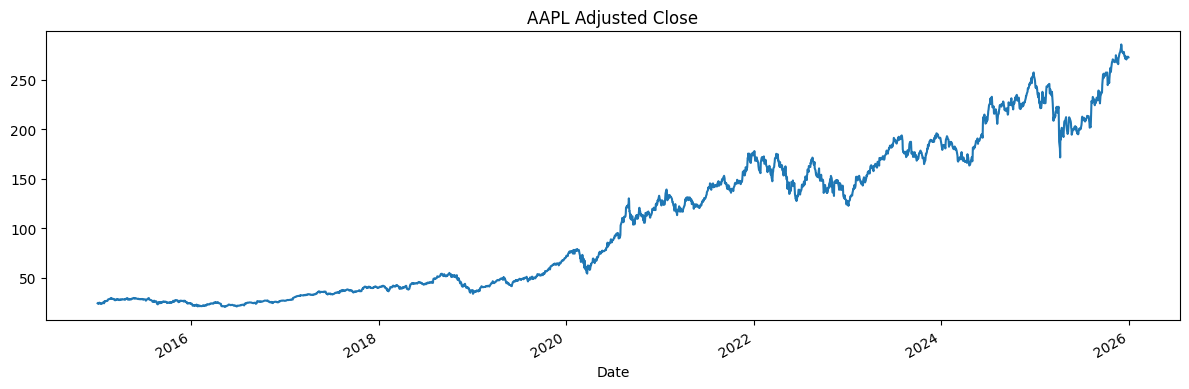


--- MACRO DATA CHECK ---
Macro shape: (4018, 9)
Columns: ['fed_funds_rate', 'cpi_inflation', 'unemployment', 'gdp_growth', 'treasury_10yr', 'treasury_2yr', 'yield_curve', 'vix', 'sp500']

--- NEWS DATA CHECK ---
News shape: (740, 6)
ticker
NVDA     100
MSFT     100
AMZN     100
AAPL      96
META      95
GOOGL     93
TSLA      74
GS        37
JPM       28
BAC       17
Name: count, dtype: int64

Recent Headlines:
0    Dell stock jumps as strong AI server demand bo...
1    Direxion Announces Date Change for Reverse Spl...
2                        tradex-backtest added to PyPI
3    CoreWeave beats revenue projections as backlog...
4    Castle Biosciences Reports Fourth Quarter and ...


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Ensuring the system path is correct for imports
sys.path.append('../..')
from src.utils.config import RAW_DIR

# Price Data 
df = pd.read_csv(
    RAW_DIR / 'price/AAPL_daily.csv',
    index_col=0, 
    parse_dates=True
)

print('--- PRICE DATA CHECK ---')
print('Shape:', df.shape)                  # Should be ~2500 rows x 5 cols
print('Dates:', df.index.min(), '->', df.index.max())
print('Missing:', df.isnull().sum().sum())  # Should be 0 or very small
print(df.tail(3))

# Plotting
df['Close'].plot(figsize=(12, 4), title='AAPL Adjusted Close')
plt.tight_layout()
plt.savefig('../../docs/aapl_check.png')
plt.show()

# Macro Data 
macro = pd.read_csv(
    RAW_DIR / 'macro/macro_indicators.csv',
    index_col=0, 
    parse_dates=True
)

print('\n--- MACRO DATA CHECK ---')
print('Macro shape:', macro.shape)
print('Columns:', list(macro.columns))

# News Data 
news = pd.read_csv(RAW_DIR / 'news/news_raw.csv')

print('\n--- NEWS DATA CHECK ---')
print('News shape:', news.shape)
if not news.empty:
    print(news['ticker'].value_counts())
    print("\nRecent Headlines:")
    print(news['title'].head(5).to_string())